# Расчётно-графическая работа №1
**Описание выборки. Оценивание параметров.
Доверительные интервалы**

In [1]:
COLUMN = 3

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math

from sires.SortedSires import SortedSires
from sires.SiresInfo import SiresInfo

from hist.Histogram import Histogram
from hist.IntervalRules import IntervalRules

from distrib.DistribType import DistribType
from distrib.Estimation import Estimation
from distrib.DistribDencity import DistribDencity
from distrib.EstimatedParamsPlots import EstimatedParamsPlots
from distrib.ParametricProb import ParametricProb
from distrib.ConfidenceIntervals import ConfidenceIntervals

from utils.Reader import Reader

from func.EmpericalDistribFunc import EmpericalDistribFunc

Читаем данные из файла и подготавливаем всякое


In [3]:
file = Reader("../RGR1_A-8_X1-X4.csv")
sorted_data = SortedSires(file.read_column(COLUMN-1))
sires_info = SiresInfo(sorted_data)

## 1 Первичное описание выборки

### 1.1 Вариационный ряд

In [4]:
sorted_data

Вариационный ряд
   Всего эдементов: 200
   Первые 5 элементов: 30.18, 32.55, 32.75, 32.98, 33.18
   Последние 5 элементов: 65.23, 64.48, 63.24, 61.78, 60.84

### 1.2 Эмпирическая функция распределения

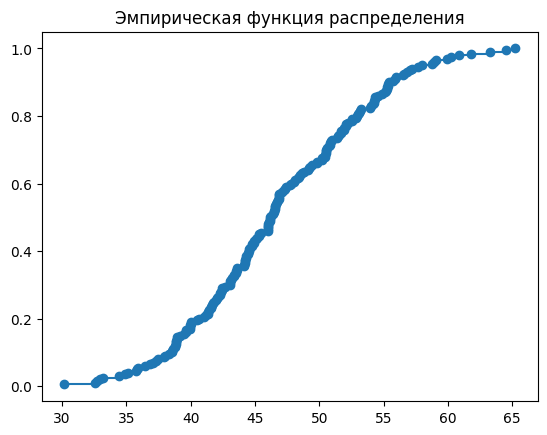

In [5]:
EmpericalDistribFunc(sorted_data).draw()
plt.show()

### 1.3 Построение гистограм

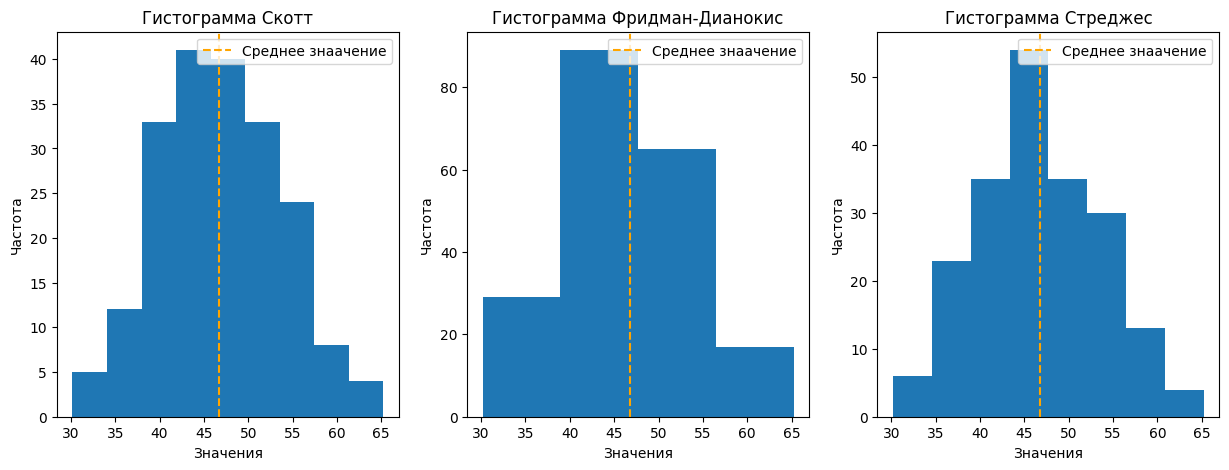

In [6]:
Histogram(sorted_data).draw_all()

### 1.4 Основные характеристики выборки

In [7]:
sires_info

Выборочные оценки:
    Среднее:                    x̄ = 46.761
    Медиана:                    x̃ =  46.230
    Размах:                     [30.2, 65.2]
    Дисперсия (смещённая):      S² =  46.853
    Дисперсия (несмещённая):    σ² =  47.088
    Ст. отклонение (смещ.):     S =  6.845
    Ст. отклонение (несмещ.):   σ =  6.862
    Квантиль 25%:               41.942
    Квантиль 50%:               46.230
    Квантиль 75%:               51.667

### Форма распределения

График симметричен\
Выбросов практически нет\
Значения ограничены естественно

## 2 Предположение о виде закона распределения


Наблюдаемое распредение - **нормальное**

График симметричен и имеет колоколообразную форму, что соответствует ключевому свойству нормального распределения.\
Наличие естественных границ значений также характерно для нормального распределения

In [10]:
dist_type = DistribType.NORMAL

In [11]:
def show_estimation_results(dist_params, dist: DistribType) -> None:
    if dist == DistribType.NORMAL:
        print("\n=== Нормальное распределение ===")
        print(f"Метод моментов: â = {dist_params[0].a:.3f},   σ̂ = {math.sqrt(dist_params[0].sigma2):.3f}")
        print(f"ММП:            â = {dist_params[1].a:.3f},   σ̂ = {math.sqrt(dist_params[1].sigma2):.3f}")

    if dist == DistribType.UNIFORM:
        print("\n=== Равномерное распределение ===")
        print(f"Метод моментов: â = {dist_params[0].a:.3f},   b̂ = {dist_params[0].b:.3f}")
        print(f"ММП:            â = {dist_params[1].a:.3f},   b̂ = {dist_params[1].b:.3f}")

    if dist == DistribType.EXP:
        print("\n=== Экспоненциальное распределение ===")
        print(f"Метод моментов: λ̂ = {dist_params[0].l:.3f},   ĉ = {dist_params[0].c:.3f}")
        print(f"ММП:            λ̂ = {dist_params[1].l:.3f},   ĉ = {dist_params[1].c:.3f}")

dist_params = Estimation(sires_info, dist_type)()
show_estimation_results(dist_params, dist_type)


=== Нормальное распределение ===
Метод моментов: â = 46.761,   σ̂ = 6.845
ММП:            â = 46.761,   σ̂ = 6.845


*Графики плотностей*

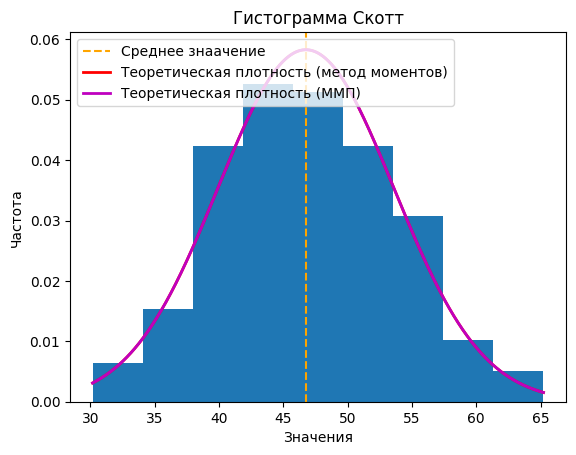

In [14]:
Histogram(sorted_data, True).draw(IntervalRules.SCOTT)

x_range = np.linspace(sorted_data.get_min(), sorted_data.get_max(), 1000)

dencity = DistribDencity(dist_params[0], dist_type).get_dencity()
y_range = [dencity(x) for x in x_range]
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Теоретическая плотность (метод моментов)')

dencity = DistribDencity(dist_params[1], dist_type).get_dencity()
y_range = [dencity(x) for x in x_range]
plt.plot(x_range, y_range, 'm-', linewidth=2, label='Теоретическая плотность (ММП)')

plt.legend(loc="upper left")
plt.show()

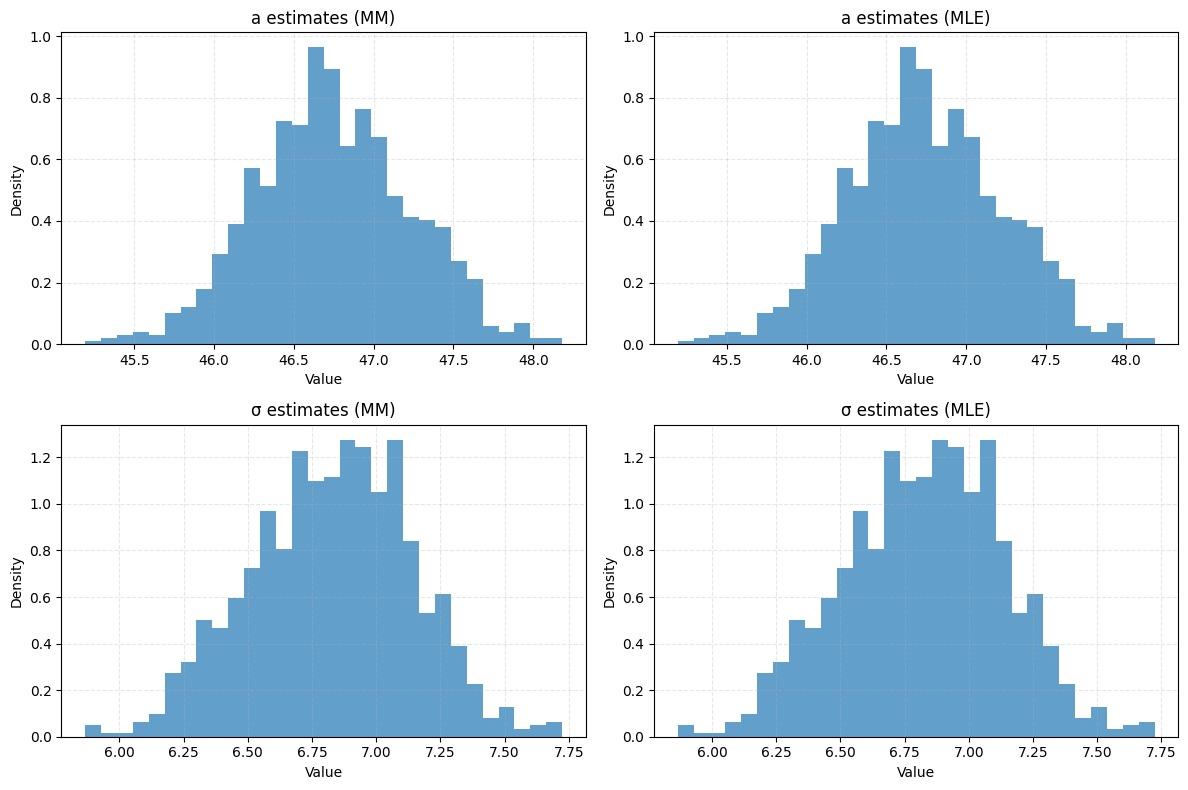

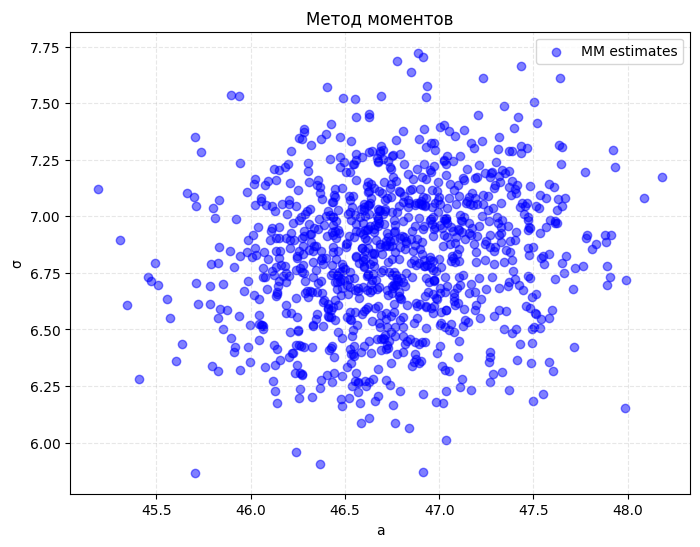

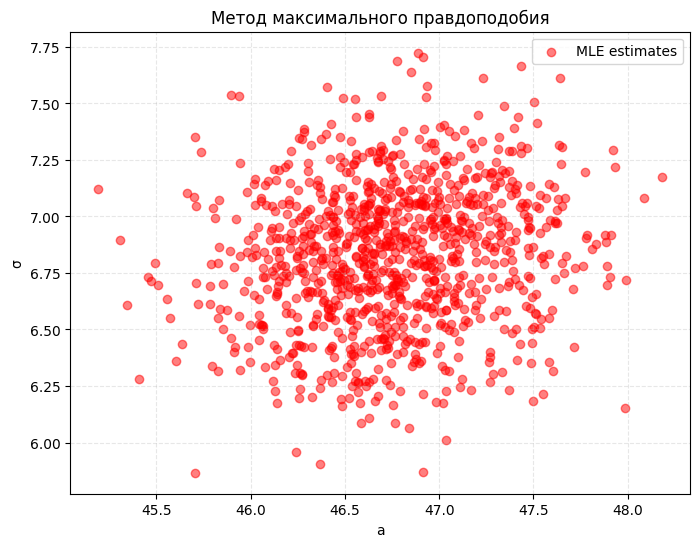

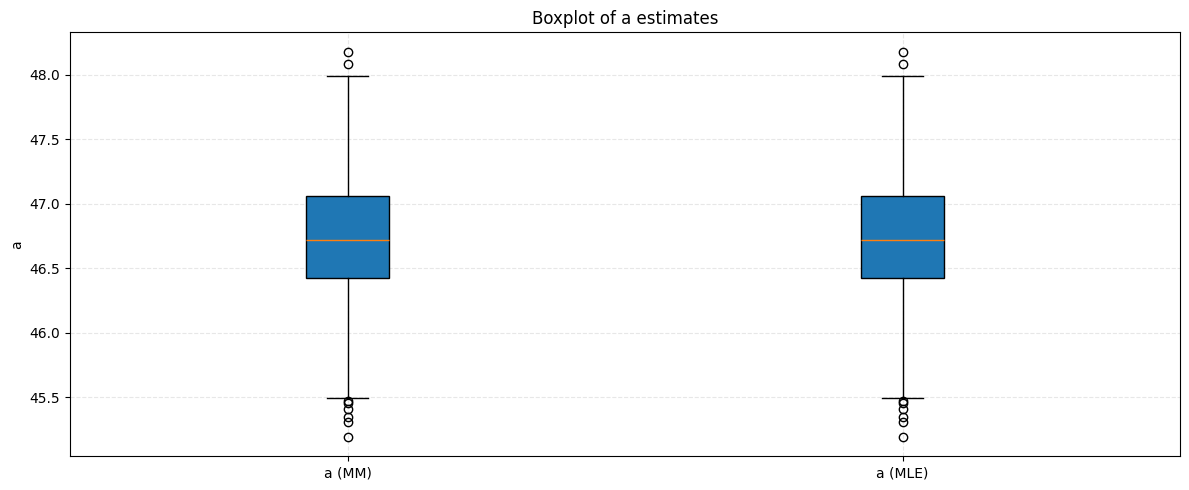

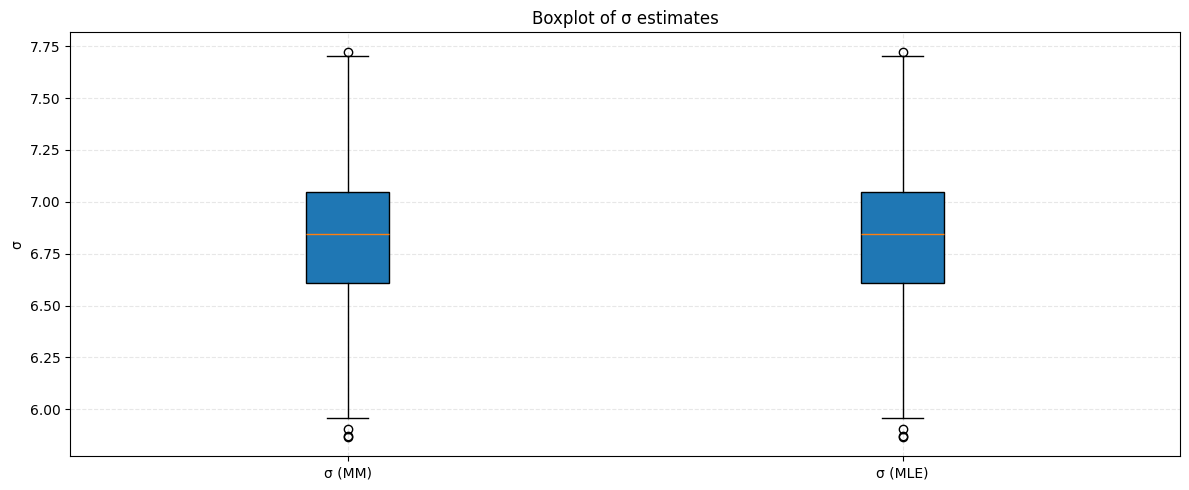

In [15]:
EstimatedParamsPlots(sorted_data, dist_type).draw()

## 4 Оценивание параметрической вероятности двумя способами

In [16]:
result = ParametricProb(sorted_data, dist_type)()
print(f"Эмпирическая оценка P(X > x0):     {result[0]:.3f}")
print(f"Параметрическая оценка P(X > x0):  {result[1]:.3f}")

Эмпирическая оценка P(X > x0):     0.180
Параметрическая оценка P(X > x0):  0.158


## 5. Оценка моментов по сгруппированной выборке

In [17]:
def grouped_moments(data: list[float], bins: int):
    n = len(data)
    counts, bin_edges = np.histogram(data, bins=bins)
    midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
    mean_grouped = np.sum(counts * midpoints) / n
    var_grouped = np.sum(counts * (midpoints - mean_grouped)**2) / (n - 1)

    return mean_grouped, var_grouped

mean_grouped, s2_grouped = grouped_moments([i for i in sorted_data], bins=7)


print("=== По исходным данным ===")
print(f"Среднее:                        {sires_info.mean:.3f}")
print(f"Дисперсия (несмещённая):        {sires_info.s2:.3f}")

print("\n=== По сгруппированной выборке ===")
print(f"Среднее:                        {mean_grouped:.3f}")
print(f"Дисперсия (несмещённая):        {s2_grouped:.3f}")

print("\n=== Абсолютные Погрешности ===")
print(f"Среднее:                        {abs(sires_info.mean - mean_grouped):.3f}")
print(f"Дисперсия (несмещённая):        {abs(sires_info.s2 - s2_grouped):.3f}")

print("\n=== Относительные Погрешности ===")
print(f"Среднее:                        {abs(sires_info.mean - mean_grouped)/sires_info.mean:.3f}")
print(f"Дисперсия (несмещённая):        {abs(sires_info.s2 - s2_grouped)/sires_info.s2:.3f}")

=== По исходным данным ===
Среднее:                        46.761
Дисперсия (несмещённая):        47.088

=== По сгруппированной выборке ===
Среднее:                        46.804
Дисперсия (несмещённая):        51.342

=== Абсолютные Погрешности ===
Среднее:                        0.043
Дисперсия (несмещённая):        4.254

=== Относительные Погрешности ===
Среднее:                        0.001
Дисперсия (несмещённая):        0.090


## 6. Доверительные интервалы

In [ ]:
_ = ConfidenceIntervals(sires_info).CPT()

print("\n=== EX по ЦПТ ===")
print(f"[{_[0]:.3f}; {_[1]:.3f}]")

if dist_type == DistribType.NORMAL:
    _ = ConfidenceIntervals(sires_info).uniform_exact()

    print("\n=== Точный μ для нормального распределения ===")
    print(f"[{_[0][0]:.3f}; {_[0][1]:.3f}]")
    print("\n=== Точный σ² для нормального распределения ===")
    print(f"[{_[1][0]:.3f}; {_[1][1]:.3f}]")


=== EX по ЦПТ ===
[45.809; 47.712]

=== Точный μ для нормального распределения ===
[45.804; 47.717]

=== Точный σ² для нормального распределения ===
[39.051; 57.905]
